# 12 · Curve fitting and property regression (refreshed classic)

Two complementary ways to turn a curve into a number:
1. **Physics** — fit the loading curve to Kick's law \(P = C\,h^{n}\) and read
   off the coefficient,
2. **Machine learning** — predict a property (hardness) from curve-derived
   features with a **Random-Forest regressor**, and check it honestly with a
   parity plot.

In [1]:
# --- setup: find the repo (auto-clone on Colab), load helpers, set plot style ---
import os, sys, subprocess
def _find_src():
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None
if _find_src() is None:                    # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)
sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import mecanano_ml as mm
mm.set_style()
print("helpers loaded from:", mm.__file__)

helpers loaded from: /tmp/stage/repo/src/mecanano_ml/__init__.py


In [2]:
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

## 1 · Physics: fit $P = C\,h^{n}$
The loading branch of an elastic–plastic indent follows a power law; `n≈2` for a geometrically self-similar tip.

C = 2.471e-04,  n = 1.89


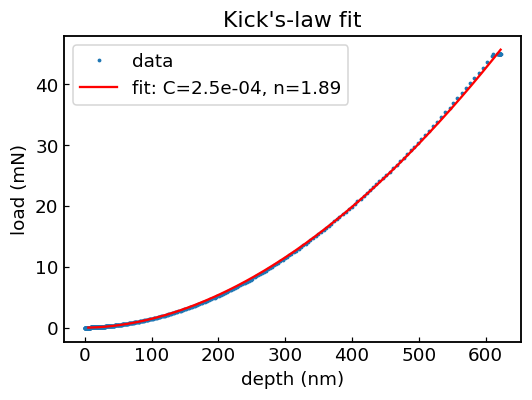

In [3]:
d, l = mm.load_curves(1)[0]
k = int(np.argmax(l)); h, P = d[:k+1], l[:k+1]
m = (h > 5) & (P > 0)                                   # skip surface noise
popt, _ = curve_fit(lambda h,C,n: C*h**n, h[m], P[m], p0=[1e-3, 2], maxfev=10000)
C, n = popt
fig, ax = plt.subplots(figsize=(5,3.8))
ax.plot(h, P, ".", ms=3, label="data")
hh = np.linspace(h[m].min(), h.max(), 200); ax.plot(hh, C*hh**n, "r-", label=f"fit: C={C:.1e}, n={n:.2f}")
ax.set_xlabel("depth (nm)"); ax.set_ylabel("load (mN)"); ax.legend(); ax.set_title("Kick's-law fit"); fig.tight_layout()
print(f"C = {C:.3e},  n = {n:.2f}")

## 2 · Machine learning: predict hardness from the curve

Across the AFM grid, build a few descriptors of each **load–depth curve** and
train a regressor to predict **hardness**. The parity plot and \(R^2\) tell you
how much of the property the curve shape really carries.

In [4]:
afm = mm.load_afm_grid()
depth = afm["depth_nm"]; loadc = afm["load_mN"]
rows = []
for i in range(loadc.shape[0]):
    rows.append(mm.curve_scalar_features(depth, loadc[i]))
F = pd.DataFrame(rows)
y = afm["H"]
ok = np.isfinite(F.values).all(1) & np.isfinite(y)
F, y = F[ok], y[ok]
print("usable indents:", len(F), " features:", list(F.columns))

usable indents: 828  features: ['P_max', 'h_max', 'S', 'We_Wt', 'C']


R² = 0.802


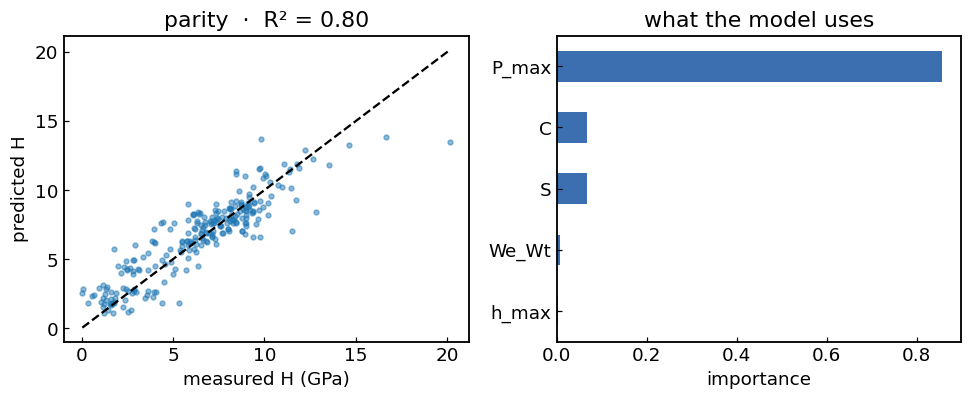

In [5]:
Xtr,Xte,ytr,yte = train_test_split(F.values, y, test_size=0.3, random_state=0)
reg = RandomForestRegressor(300, random_state=0, n_jobs=-1).fit(Xtr, ytr)
pred = reg.predict(Xte)
r2 = r2_score(yte, pred)
fig, ax = plt.subplots(1,2, figsize=(9,3.8))
ax[0].scatter(yte, pred, s=10, alpha=.5); lim=[min(yte.min(),pred.min()), max(yte.max(),pred.max())]
ax[0].plot(lim,lim,"k--"); ax[0].set_xlabel("measured H (GPa)"); ax[0].set_ylabel("predicted H")
ax[0].set_title(f"parity  ·  R² = {r2:.2f}")
imp = pd.Series(reg.feature_importances_, index=F.columns).sort_values()
imp.plot.barh(ax=ax[1], color="#3b6fb0"); ax[1].set_xlabel("importance"); ax[1].set_title("what the model uses")
fig.tight_layout()
print("R² =", round(r2,3))

## Recap
- **Physics fits** give interpretable coefficients (`C`, `n`) directly from a curve.
- A **Random-Forest regressor** learns a property from curve descriptors; the
  **parity plot / R²** keeps you honest about what the curve can and cannot predict.
- Compare the two: where the physical model breaks down, ML can still capture
  the trend — but only report what the validation supports.